In [1]:
import pandas as pd
import missingno
enc = 'utf-8' 
dec = 'greek8'

In [2]:
def describe_dataframe(frame):
    df_desc = pd.DataFrame(columns=['Column', 'Missing'])

    for col in frame.columns:
        df_desc = df_desc.append({'Column': col, 
                                'Missing': (frame[col].isnull().sum() * 100 / len(frame[col]))}, ignore_index = True)
    
    return df_desc

def process_greek(frame, column):
    frame[column] = frame[column].apply(lambda x : x.strip())
    frame[column] = frame[column].apply(lambda x : x.lower())
    frame[column] = frame[column].apply(lambda x : x.replace('ά','α'))
    frame[column] = frame[column].apply(lambda x : x.replace('έ','ε'))
    frame[column] = frame[column].apply(lambda x : x.replace('ή','η'))
    frame[column] = frame[column].apply(lambda x : x.replace('ί','ι'))
    frame[column] = frame[column].apply(lambda x : x.replace('ύ','υ'))
    frame[column] = frame[column].apply(lambda x : x.replace('ό','ο'))
    frame[column] = frame[column].apply(lambda x : x.replace('ώ','ω'))


In [3]:
raw_data = pd.read_csv('data/GR_WNV_cases_2010-2021_raw.csv', encoding = enc)
raw_data.head(5)

,αα,Id διαχείρισης δεδομένων,Έτος,Ηλικία \n(σε έτη),Φύλο,Ημ/νία έναρξης συμπτωμάτων,Προσβολή ΚΝΣ (ΝΑΙ/ΟΧΙ),Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Πόλη/χωριό (/συνοικία Αθήνας) πιθανής έκθεσης,Κωδικός κανάβου κελιού 1x1 χλμ πιθανής έκθεσης,Unnamed: 12
0,1.0,3.0,2010.0,75.0,ΘΗΛΥ,28-07-10,NAI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",NaN,NaN
1,2.0,17.0,2010.0,78.0,ΑΡΡΕΝ,22-07-10,NAI,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,NaN,NaN
2,3.0,4.0,2010.0,70.0,ΘΗΛΥ,24-07-10,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,NaN,NaN
3,4.0,21.0,2010.0,74.0,ΑΡΡΕΝ,30-7-2010,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,NaN,NaN
4,5.0,59.0,2010.0,19.0,ΘΗΛΥ,06-07-10,NAI,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,NaN,NaN


In [4]:
raw_data.shape

(1421, 13)

In [5]:
data = raw_data.set_axis(['idx', 'id', 'year', 'age', 'sex', 'onset of symptoms', 'cns attack', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code', 'unnamed'], axis=1, inplace=False)

In [6]:
data.drop(columns = ['idx', 'id', 'cell_code', 'unnamed'], inplace = True)
data.head(5)

,year,age,sex,onset of symptoms,cns attack,nuts2,nuts3,lau1,lau2
0,2010.0,75.0,ΘΗΛΥ,28-07-10,NAI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη"
1,2010.0,78.0,ΑΡΡΕΝ,22-07-10,NAI,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια
2,2010.0,70.0,ΘΗΛΥ,24-07-10,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι
3,2010.0,74.0,ΑΡΡΕΝ,30-7-2010,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη
4,2010.0,19.0,ΘΗΛΥ,06-07-10,NAI,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο


In [7]:
df_missign = describe_dataframe(data)

df_missign

,Column,Missing
0,year,0.070373
1,age,0.070373
2,sex,0.070373
3,onset of symptoms,1.055595
4,cns attack,0.070373
5,nuts2,0.211119
6,nuts3,0.211119
7,lau1,0.211119
8,lau2,0.211119


In [8]:
data.dropna(axis = 0, subset = ['onset of symptoms', 'lau1'], how = 'any', inplace = True)
data['onset of symptoms'] = data['onset of symptoms'].apply(lambda x : x.replace("~", ""))
data = data[data['onset of symptoms'] != 'Άγνωστη']
data = data[data['nuts2'] != 'Άγνωστη']
data = data[data['nuts2'] != 'Απροσδιόριστη']
data = data[data['nuts2'] != 'Απροσδιόριστη (Ανατολικής Μακεδονίας & Θράκης Ή Κεντρικής Μακεδονίας)']

In [9]:
df_missign = describe_dataframe(data)

df_missign

,Column,Missing
0,year,0.0
1,age,0.0
2,sex,0.0
3,onset of symptoms,0.0
4,cns attack,0.0
5,nuts2,0.0
6,nuts3,0.0
7,lau1,0.0
8,lau2,0.0


In [10]:
data.shape

(1394, 9)

In [11]:
data['onset of symptoms'] = pd.to_datetime(data['onset of symptoms'], dayfirst=True, errors='coerce')

In [12]:
data

,year,age,sex,onset of symptoms,cns attack,nuts2,nuts3,lau1,lau2
0,2010.0,75.0,ΘΗΛΥ,2010-07-28,NAI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη"
1,2010.0,78.0,ΑΡΡΕΝ,2010-07-22,NAI,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια
2,2010.0,70.0,ΘΗΛΥ,2010-07-24,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι
3,2010.0,74.0,ΑΡΡΕΝ,2010-07-30,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη
4,2010.0,19.0,ΘΗΛΥ,2010-07-06,NAI,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο
...,...,...,...,...,...,...,...,...,...
1414,2021.0,46.0,ΑΡΡΕΝ,2021-08-31,OXI,Ανατολικής Μακεδονίας & Θράκης,Καβάλας,Παγγαίου,Παραλία Οφρυνίου (Τούζλα)
1415,2021.0,85.0,ΑΡΡΕΝ,2021-09-13,OXI,Κεντρικής Μακεδονίας,Ημαθίας,Ηρωικής πόλης Νάουσας,Αγγελοχώρι
1416,2021.0,52.0,ΘΗΛΥ,2021-09-03,OXI,Κεντρικής Μακεδονίας,Ημαθίας,Αλεξάνδρειας,Πλατύ
1418,2021.0,65.0,ΑΡΡΕΝ,2021-10-04,OXI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θερμαϊκού,Περαία


In [13]:
data.dropna(axis = 0, subset = ['onset of symptoms'], how = 'any', inplace = True)

In [14]:
data

,year,age,sex,onset of symptoms,cns attack,nuts2,nuts3,lau1,lau2
0,2010.0,75.0,ΘΗΛΥ,2010-07-28,NAI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη"
1,2010.0,78.0,ΑΡΡΕΝ,2010-07-22,NAI,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια
2,2010.0,70.0,ΘΗΛΥ,2010-07-24,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι
3,2010.0,74.0,ΑΡΡΕΝ,2010-07-30,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη
4,2010.0,19.0,ΘΗΛΥ,2010-07-06,NAI,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο
...,...,...,...,...,...,...,...,...,...
1414,2021.0,46.0,ΑΡΡΕΝ,2021-08-31,OXI,Ανατολικής Μακεδονίας & Θράκης,Καβάλας,Παγγαίου,Παραλία Οφρυνίου (Τούζλα)
1415,2021.0,85.0,ΑΡΡΕΝ,2021-09-13,OXI,Κεντρικής Μακεδονίας,Ημαθίας,Ηρωικής πόλης Νάουσας,Αγγελοχώρι
1416,2021.0,52.0,ΘΗΛΥ,2021-09-03,OXI,Κεντρικής Μακεδονίας,Ημαθίας,Αλεξάνδρειας,Πλατύ
1418,2021.0,65.0,ΑΡΡΕΝ,2021-10-04,OXI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θερμαϊκού,Περαία


In [15]:
nuts2 = data['nuts2'].drop_duplicates().sort_values().tolist()
nuts3 = data['nuts3'].drop_duplicates().sort_values().tolist()
lau1 = data['lau1'].drop_duplicates().sort_values().tolist()
lau2 = data['lau2'].drop_duplicates().sort_values().tolist()

In [16]:
with open('data/GR_WNV_nuts2.txt', 'w', encoding=enc) as f:
    for item in nuts2:
        f.write("%s\n" % item)
        
with open('data/GR_WNV_nuts3.txt', 'w', encoding=enc) as f:
    for item in nuts3:
        f.write("%s\n" % item)
        
with open('data/GR_WNV_lau1.txt', 'w', encoding=enc) as f:
    for item in lau1:
        f.write("%s\n" % item)
        
with open('data/GR_WNV_lau2.txt', 'w', encoding=enc) as f:
    for item in lau2:
        f.write("%s\n" % item)

<AxesSubplot:>

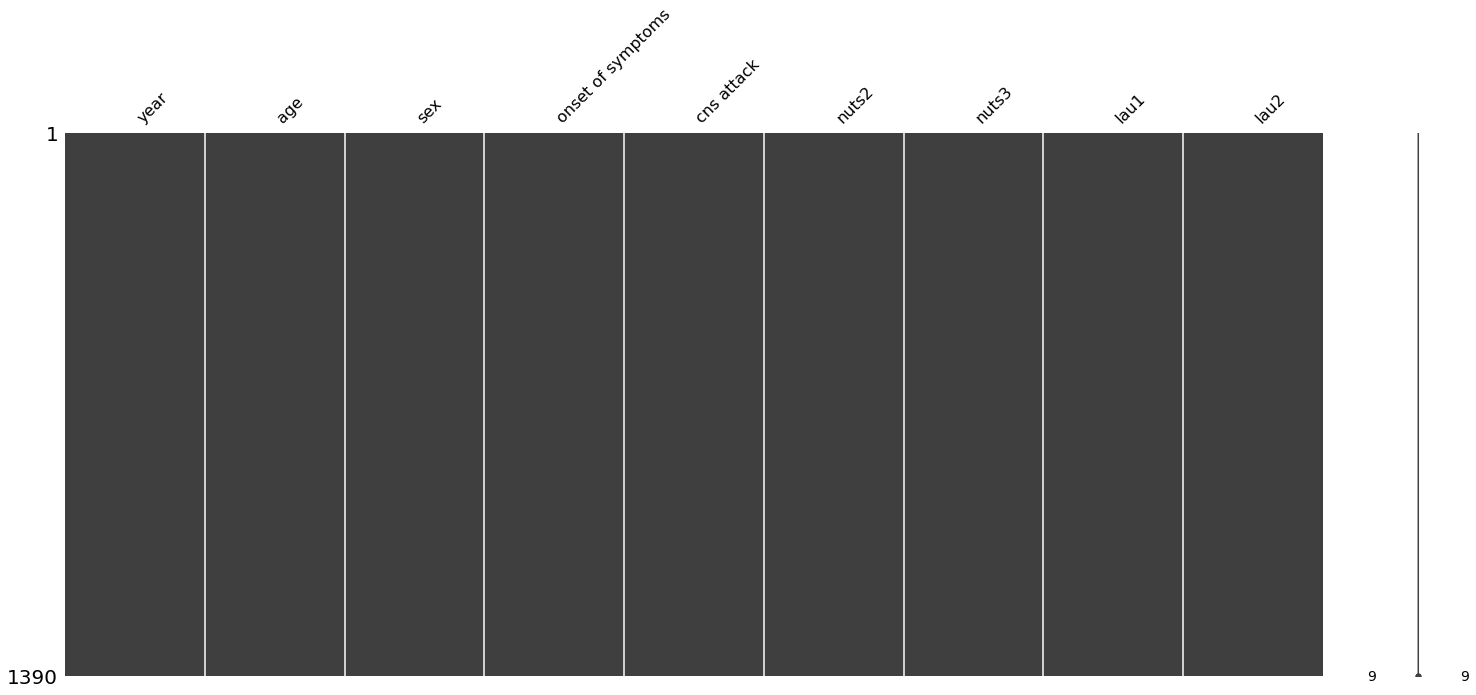

In [17]:
missingno.matrix(data)

In [18]:
process_greek(data, 'nuts2')
process_greek(data, 'nuts3')
process_greek(data, 'lau1')
process_greek(data, 'lau2')

In [19]:
data

,year,age,sex,onset of symptoms,cns attack,nuts2,nuts3,lau1,lau2
0,2010.0,75.0,ΘΗΛΥ,2010-07-28,NAI,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη"
1,2010.0,78.0,ΑΡΡΕΝ,2010-07-22,NAI,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια
2,2010.0,70.0,ΘΗΛΥ,2010-07-24,NAI,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι
3,2010.0,74.0,ΑΡΡΕΝ,2010-07-30,NAI,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη
4,2010.0,19.0,ΘΗΛΥ,2010-07-06,NAI,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο
...,...,...,...,...,...,...,...,...,...
1414,2021.0,46.0,ΑΡΡΕΝ,2021-08-31,OXI,ανατολικης μακεδονιας & θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα)
1415,2021.0,85.0,ΑΡΡΕΝ,2021-09-13,OXI,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι
1416,2021.0,52.0,ΘΗΛΥ,2021-09-03,OXI,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ
1418,2021.0,65.0,ΑΡΡΕΝ,2021-10-04,OXI,κεντρικης μακεδονιας,θεσσαλονικης,θερμαϊκου,περαια


In [20]:
data['day'] = data['onset of symptoms'].apply(lambda x : x.day)
data['month'] = data['onset of symptoms'].apply(lambda x : x.month)

In [21]:
nuts2_processed = data['nuts2'].drop_duplicates().sort_values().tolist()
nuts3_processed = data['nuts3'].drop_duplicates().sort_values().tolist()
lau1_processed = data['lau1'].drop_duplicates().sort_values().tolist()
lau2_processed = data['lau2'].drop_duplicates().sort_values().tolist()

In [22]:
with open('data/GR_WNV_nuts2_processed.txt', 'w', encoding=enc) as f:
    for item in nuts2_processed:
        f.write("%s\n" % item)
        
with open('data/GR_WNV_nuts3_processed.txt', 'w', encoding=enc) as f:
    for item in nuts3_processed:
        f.write("%s\n" % item)
        
with open('data/GR_WNV_lau1_processed.txt', 'w', encoding=enc) as f:
    for item in lau1_processed:
        f.write("%s\n" % item)
        
with open('data/GR_WNV_lau2_processed.txt', 'w', encoding=enc) as f:
    for item in lau2_processed:
        f.write("%s\n" % item)

In [23]:
data

,year,age,sex,onset of symptoms,cns attack,nuts2,nuts3,lau1,lau2,day,month
0,2010.0,75.0,ΘΗΛΥ,2010-07-28,NAI,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",28,7
1,2010.0,78.0,ΑΡΡΕΝ,2010-07-22,NAI,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,22,7
2,2010.0,70.0,ΘΗΛΥ,2010-07-24,NAI,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,24,7
3,2010.0,74.0,ΑΡΡΕΝ,2010-07-30,NAI,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,30,7
4,2010.0,19.0,ΘΗΛΥ,2010-07-06,NAI,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,6,7
...,...,...,...,...,...,...,...,...,...,...,...
1414,2021.0,46.0,ΑΡΡΕΝ,2021-08-31,OXI,ανατολικης μακεδονιας & θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),31,8
1415,2021.0,85.0,ΑΡΡΕΝ,2021-09-13,OXI,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,13,9
1416,2021.0,52.0,ΘΗΛΥ,2021-09-03,OXI,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,3,9
1418,2021.0,65.0,ΑΡΡΕΝ,2021-10-04,OXI,κεντρικης μακεδονιας,θεσσαλονικης,θερμαϊκου,περαια,4,10


In [24]:
sexes = {'ΘΗΛΥ': 'f', 'ΑΡΡΕΝ': 'm'}
data['sex'] = data['sex'].map(sexes)  

In [25]:
data = data.reindex(columns=['onset of symptoms', 'year', 'month', 'day', 'nuts2', 'nuts3', 'lau1', 'lau2', 'age', 'sex'])

In [26]:
data

,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,age,sex
0,2010-07-28,2010.0,7,28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",75.0,f
1,2010-07-22,2010.0,7,22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,78.0,m
2,2010-07-24,2010.0,7,24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,70.0,f
3,2010-07-30,2010.0,7,30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,74.0,m
4,2010-07-06,2010.0,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,19.0,f
...,...,...,...,...,...,...,...,...,...,...
1414,2021-08-31,2021.0,8,31,ανατολικης μακεδονιας & θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),46.0,m
1415,2021-09-13,2021.0,9,13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,85.0,m
1416,2021-09-03,2021.0,9,3,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,52.0,f
1418,2021-10-04,2021.0,10,4,κεντρικης μακεδονιας,θεσσαλονικης,θερμαϊκου,περαια,65.0,m


In [27]:
data = data.astype({"year":'int', "age":'int'})

In [28]:
data

,onset of symptoms,year,month,day,nuts2,nuts3,lau1,lau2,age,sex
0,2010-07-28,2010,7,28,κεντρικης μακεδονιας,θεσσαλονικης,θεσσαλονικης,"παπαφη, θεσσαλονικη",75,f
1,2010-07-22,2010,7,22,κεντρικης μακεδονιας,ημαθιας,βεροιας,βεροια,78,m
2,2010-07-24,2010,7,24,κεντρικης μακεδονιας,κιλκις,κιλκις,λεβεντοχωρι,70,f
3,2010-07-30,2010,7,30,κεντρικης μακεδονιας,κιλκις,κιλκις,καμπανη,74,m
4,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,ηρακλειας,ποντισμενο,19,f
...,...,...,...,...,...,...,...,...,...,...
1414,2021-08-31,2021,8,31,ανατολικης μακεδονιας & θρακης,καβαλας,παγγαιου,παραλια οφρυνιου (τουζλα),46,m
1415,2021-09-13,2021,9,13,κεντρικης μακεδονιας,ημαθιας,ηρωικης πολης ναουσας,αγγελοχωρι,85,m
1416,2021-09-03,2021,9,3,κεντρικης μακεδονιας,ημαθιας,αλεξανδρειας,πλατυ,52,f
1418,2021-10-04,2021,10,4,κεντρικης μακεδονιας,θεσσαλονικης,θερμαϊκου,περαια,65,m


In [29]:
df_missign = describe_dataframe(data)

df_missign

,Column,Missing
0,onset of symptoms,0.0
1,year,0.0
2,month,0.0
3,day,0.0
4,nuts2,0.0
5,nuts3,0.0
6,lau1,0.0
7,lau2,0.0
8,age,0.0
9,sex,0.0


In [30]:
data.to_csv("data/GR_WNV_cases_2010-2021_processed.csv", encoding = enc, index = False)